In [1]:
!pip install tf-levenberg-marquardt

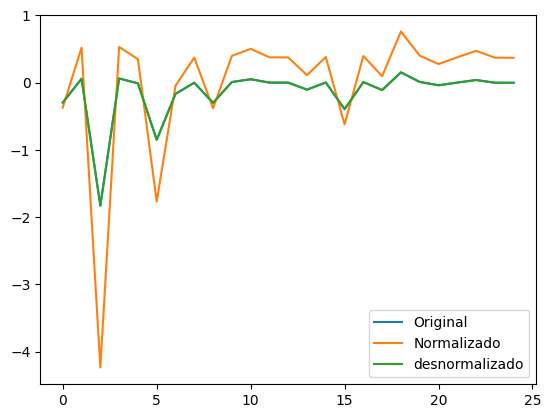

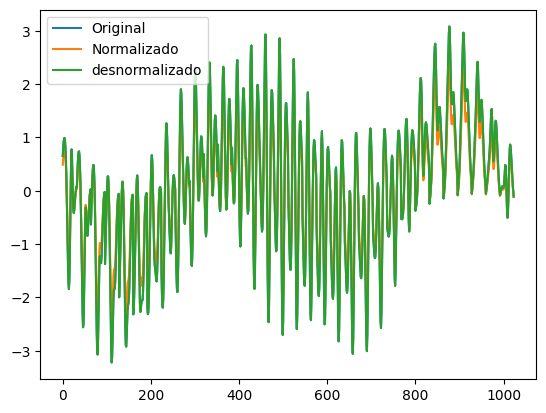

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
out_scaler = StandardScaler()

def peaks(grid):
    x = np.linspace(-2, 2, grid)
    y = np.linspace(-2, 2, grid)
    x, y = np.meshgrid(x, y)
    z = 3*(1-x)**2 * np.exp(-(x**2) - (y+1)**2) - 10*(x/5 - x**3 - y**5) * np.exp(-x**2 - y**2) - 1/3 * np.exp(-(x+1)**2 - y**2)
    return x, y, z

def create_dataframe_(filepath, grid):
    x = np.linspace(-2, 2, grid)
    y = np.linspace(-2, 2, grid)
    x, y = np.meshgrid(x, y)
    z = 3*(1-x)**2 * np.exp(-(x**2) - (y+1)**2) - 10*(x/5 - x**3 - y**5) * np.exp(-x**2 - y**2) - 1/3 * np.exp(-(x+1)**2 - y**2)
    df_pred = pd.read_excel(filepath)
    z_pred = df_pred['Z_pred'].values
    z_residuo= z.flatten() - z_pred
    data = {'X': x.flatten(), 'Y': y.flatten(), 'Z': z_residuo}
    df = pd.DataFrame(data)
    return df
 
def create_dataframe(grid):
   x, y, z = peaks(grid)
   data = {'X': x.flatten(), 'Y': y.flatten(), 'Z': z.flatten()}
   df = pd.DataFrame(data)
   return df

def show_norm(df, label="Peaks", plot=False):
    df_norm = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
    df_denorm = pd.DataFrame(scaler.inverse_transform(df_norm), columns=df_norm.columns)

    if (plot):
        df.plot(title=f"{label}: Original data")
        df_norm.plot(title=f"{label}: Normalized data")
        df_denorm.plot(title=f"{label}: Denormalized data")
    return (df_norm)


def test_out_scaler(df):
    out = df["Z"].values.reshape(-1, 1)  
    plt.plot(out, label='Original')
    out_scaler.fit(out)
    norm = out_scaler.transform(out)
    plt.plot(norm, label='Normalizado')
    plt.plot(out_scaler.inverse_transform(norm), label='desnormalizado')
    plt.legend()
    plt.show()


df_25 = create_dataframe_(f"25_model_12_6_0.xlsx", grid=5)
df_25_norm = show_norm(df_25)
test_out_scaler(df_25)

df_1000 = create_dataframe_(f"1000_model_12_6_0.xlsx",grid=32)
df_1000_norm = show_norm(df_1000)
test_out_scaler(df_1000)

def split_df(df):
    _input = np.vstack([df['X'], df['Y']]).T
    _output = np.array(df['Z'])
    return (_input, _output)

In [3]:
import tensorflow as tf
import numpy as np
from keras import regularizers
from keras import initializers
import tf_levenberg_marquardt as lm

# layers, neurons
class ShuffleArchitecture:
    def __init__(self, input_size, hidden_sizes, output_size, act_h, act_o, param_reg):
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        self.act_h = act_h
        self.act_o = act_o
        self.regularizer = regularizers.L2(param_reg)
        self.initializer = initializers.RandomUniform(minval=-0.5, maxval=0.5, seed=np.random.randint(1, 10000))

    def compute_k(self):
        total_parameters = 0
        for layer in self.model.layers:
            weights = layer.get_weights()
            if len(weights) > 0:  
                for w in weights:
                    total_parameters += np.prod(w.shape)
        return total_parameters
        
    def set_architecture(self):
        self.model = tf.keras.Sequential()
        self.model.add(tf.keras.layers.Dense(self.hidden_sizes[0],
                        input_shape=(self.input_size,),
                        activation=self.act_h,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,                        
                        ))  # input layer

        for size in self.hidden_sizes[1:]:  # hidden layers
            self.model.add(tf.keras.layers.Dense(size,
                            activation=self.act_h,
                            kernel_regularizer=self.regularizer,
                            kernel_initializer=self.initializer,  
                        ))

        self.model.add(tf.keras.layers.Dense(self.output_size,
                        activation=self.act_o,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,  
                        ))  # output layer

    def create_model(self, _learning_rate):

        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=_learning_rate),
            loss='mean_squared_error',
            metrics=['mse'])

        self.lm_model = lm.model.ModelWrapper(
            tf.keras.models.clone_model(self.model))
  

        self.lm_model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=_learning_rate),
            loss='mean_squared_error')
        
        return(self.lm_model)


2025-10-19 15:32:55.555994: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-19 15:32:55.612542: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-19 15:32:55.612597: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-19 15:32:55.614183: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-19 15:32:55.621008: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-19 15:32:55.621476: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [7]:
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 
import plotly.figure_factory as ff
import plotly.offline as py
from scipy.spatial import Delaunay
import plotly.graph_objs as go


class Rebuild:
    def __init__(self):
        self.df = pd.read_excel(f"better_results.xlsx")        
        self.sup_input, self.sup_output = split_df(df_1000_norm)
        self.matriz= np.empty((0, 0))

    def LoadModelWeights(self, model, fileName):        
        path = f"content/models/{fileName}.keras"
        model.load_weights(path)

    def LoadPrevDataset(self, fileName):
        fileName = fileName.replace("model", "dataset")
        pos = fileName.rfind("_")
        path = f"content/dataset/{fileName[:pos]}.pkl" 
        with open(path, 'rb') as f:
            _data, _train, _vt, _val, _test = pickle.load(f)
        self._data, self._train, self._vt, self._val, self._test = _data, _train, _vt, _val, _test    
    
    def setArchitecture(self, _hidden_sizes, _pg, _lr):
        shuffler = ShuffleArchitecture(input_size = 2,
                                    hidden_sizes = _hidden_sizes,
                                    output_size = 1,
                                    act_h = 'tanh',
                                    act_o = 'linear',
                                    param_reg = _pg)
        shuffler.set_architecture()
        self.k = shuffler.compute_k()
        return(shuffler.create_model(_lr))            

    def getArchitecture(self, architecture):
        hidden_size = [int(x) for x in architecture.split("[")[1].split("]")[0].split(", ")]
        regularizer = float(architecture.split("regularizer=")[1].split(",")[0])
        learning_rate = float(architecture.split("learning_rate=")[1])
        return hidden_size, regularizer, learning_rate

    def PlotResults(self, original_values, predicted_values):
        titles = ['Original vs. Preditos (Completo)',
                    'Original vs. Preditos (Teste)',
                    'Original vs. Preditos (Validação)',
                    'Original vs. Preditos (Validação e Teste)']
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        for i, ax in enumerate(axes.flat):
            ax.plot(original_values[i], label='Original')
            ax.plot(predicted_values[i], label='Preditos')
            ax.set_title(titles[i])
            ax.legend()
        plt.tight_layout()
        plt.show()

    def matriz_Z_pred(self,predicted_values):
        
        if self.matriz.size == 0:
            # Inicializa a matriz com o primeiro vetor como a primeira coluna
            self.matriz = np.expand_dims(predicted_values, axis=1)
        else:
            # Verifica se o vetor tem o mesmo número de linhas que a matriz
            if self.matriz.shape[0] == predicted_values.shape[0]:
                # Expande a matriz com o novo vetor como uma nova coluna
                self.matriz = np.column_stack((self.matriz, predicted_values))
       
    def get_matrix(self):
        # Retorna a matriz atual
        return self.matriz
    
    def sum_rows_and_divide_by_10(self, original_values):
        if self.matriz.size == 10:
            row_sums = np.sum(self.matriz, axis=1)
            row_sums_divided = np.zeros_like(row_sums)
            row_sums_divided = row_sums / 10
            coluna_np = np.array(row_sums_divided)
            coluna_np1=np.expand_dims(coluna_np, axis=1) 
            x, y, z = df_1000['X'], df_1000['Y'], df_1000['Z']
            points = np.column_stack((x, y))
            tri = Delaunay(points)
            
            fig_original = ff.create_trisurf(x=x, y=y, z=original_values.flatten(), 
                                            simplices=tri.simplices, colormap='Greys',
                                            title='Surface Fit - Original Values')

            fig_predicted = ff.create_trisurf(x=x, y=y, z=coluna_np1, 
                                            simplices=tri.simplices, colormap='Viridis',
                                            title='Surface Fit - Predicted Values')

            data = [fig_original.data[0], fig_predicted.data[0], ]
            fig = go.Figure(data=data)
            fig.update_layout(title='Surface Fit', autosize=False,
                    width=500, height=500,
                    margin=dict(l=65, r=50, b=65, t=90))
            fig.show()

    def PlotSurface(self, original_values, predicted_values, model):
        x, y, z = df_1000['X'], df_1000['Y'], df_1000['Z']
        points = np.column_stack((x, y))
        tri = Delaunay(points)
        
        fig_original = ff.create_trisurf(x=x, y=y, z=original_values.flatten(), 
                                        simplices=tri.simplices, colormap='Greys',
                                        title='Surface Fit - Original Values')

        fig_predicted = ff.create_trisurf(x=x, y=y, z=predicted_values.flatten(), 
                                        simplices=tri.simplices, colormap='Viridis',
                                        title='Surface Fit - Predicted Values')

        data = [fig_original.data[0], fig_predicted.data[0], ]
        fig = go.Figure(data=data)
        fig.update_layout(title='Surface Fit', autosize=False,
                  width=500, height=500,
                  margin=dict(l=65, r=50, b=65, t=90))
        fig.show()

    def get_new_metrics(self, orig, pred, r2, mse):
      n = len(orig) # N: quantidade de saidas
      k = self.k
      waste = (orig.flatten() - pred.flatten())

      mape = mean_absolute_percentage_error(orig, pred)  
      r2_adj = 1 - (((n - 1)/(n - k - 1)) * (1 - r2))
      rsd = np.sqrt(np.sum(waste ** 2) / (n - 2))
      rmse = root_mean_squared_error(orig, pred)          
      aic = (-2 * np.log(mse)) + (2 * k)
      bic = (-2 * np.log(mse)) + (k * np.log(n))
      return (mape, r2_adj, rsd, rmse, aic, bic)

    def RecalcMetrics(self, idx,
                        out_denorm, test_denorm, val_denorm, vt_denorm, sup_denorm,
                        pred_denorm, test_pred_denorm, val_pred_denorm, vt_pred_denorm, sup_pred_denorm):
        r2 = r2_score(out_denorm, pred_denorm)
        r2_test = r2_score(test_denorm, test_pred_denorm)
        r2_val = r2_score(val_denorm, val_pred_denorm)
        r2_vt = r2_score(vt_denorm,  vt_pred_denorm)
        r2_sup = r2_score(sup_denorm,  sup_pred_denorm)

        mse = mean_squared_error(out_denorm, pred_denorm)
        mse_test = mean_squared_error(test_denorm, test_pred_denorm)
        mse_val = mean_squared_error(val_denorm, val_pred_denorm)
        mse_vt = mean_squared_error(vt_denorm,  vt_pred_denorm)
        mse_sup = mean_squared_error(sup_denorm,  sup_pred_denorm)
        
        mape, r2_adj, rsd, rmse, aic, bic = self.get_new_metrics(out_denorm, pred_denorm, r2, mse)
        self.df.loc[idx, 'r2'] = r2
        self.df.loc[idx, 'r2_sup'] = r2_sup
        self.df.loc[idx, 'r2_test'] = r2_test
        self.df.loc[idx, 'r2_val'] = r2_val
        self.df.loc[idx, 'r2_vt'] = r2_vt
        self.df.loc[idx, 'mse'] = mse
        self.df.loc[idx, 'mse_sup'] = mse_sup
        self.df.loc[idx, 'mse_test'] = mse_test
        self.df.loc[idx, 'mse_val'] = mse_val
        self.df.loc[idx, 'mse_vt'] = mse_vt
        self.df.loc[idx, 'mape'] = mape
        self.df.loc[idx, 'rmse'] = rmse
        self.df.loc[idx, 'r2_adj'] = r2_adj
        self.df.loc[idx, 'rsd'] = rsd
        self.df.loc[idx, 'aic'] = aic
        self.df.loc[idx, 'bic'] = bic

    def print_MSE(self, original_values, predicted_values):
        MSE_sup= mean_squared_error(original_values,predicted_values)
        mse_sup = f"\nMSE de superficie: {MSE_sup}\n"
        return mse_sup

    
    def GetOuts(self, df, out_denorm, pred_denorm, fileName):
        input, output = split_df(df)
        
        data = {'X': input[:, 0].flatten(),
                'Y': input[:, 0].flatten(),
                'Z': out_denorm.flatten(),
                'Z_pred': pred_denorm.flatten()}
        
        df = pd.DataFrame(data)
        df.to_excel(f"{fileName}.xlsx", index=False)


    def predictResults(self, idx=-1):
        pred = self.lm_model.predict(self._data[0]).flatten()
        test_pred = self.lm_model.predict(self._test[0]).flatten()
        val_pred = self.lm_model.predict(self._val[0]).flatten()
        vt_pred = self.lm_model.predict(self._vt[0]).flatten()
        sup_pred = self.lm_model.predict(self.sup_input).flatten()

        # Calculando as metricas com a saida desnormalizada
        pred_denorm = out_scaler.inverse_transform(pred.reshape(-1, 1))
        test_pred_denorm = out_scaler.inverse_transform(test_pred.reshape(-1, 1))
        val_pred_denorm = out_scaler.inverse_transform(val_pred.reshape(-1, 1))
        vt_pred_denorm = out_scaler.inverse_transform(vt_pred.reshape(-1, 1))
        sup_pred_denorm = out_scaler.inverse_transform(sup_pred.reshape(-1, 1))

        out_denorm = out_scaler.inverse_transform(self._data[1].reshape(-1, 1))
        test_denorm = out_scaler.inverse_transform(self._test[1].reshape(-1, 1))
        val_denorm = out_scaler.inverse_transform(self._val[1].reshape(-1, 1))
        vt_denorm = out_scaler.inverse_transform(self._vt[1].reshape(-1, 1))
        sup_denorm = out_scaler.inverse_transform(self.sup_output.reshape(-1, 1))

        original_values = [out_denorm, test_denorm, val_denorm, vt_denorm, sup_denorm]
        predicted_values = [pred_denorm, test_pred_denorm, val_pred_denorm, vt_pred_denorm, sup_pred_denorm]

        if (idx != -1):
            self.RecalcMetrics(idx,
                                out_denorm, test_denorm, val_denorm, vt_denorm, sup_denorm,
                                pred_denorm, test_pred_denorm, val_pred_denorm, vt_pred_denorm, sup_pred_denorm)            
        return (original_values, predicted_values)


    def FixWrongMetrics(self):
        i = 0
        for file_model, architecture in zip(self.df["model"], self.df["Architecture"]):
            hidden_size, regularizer, learning_rate = self.getArchitecture(architecture)
            self.lm_model = self.setArchitecture(hidden_size, regularizer, learning_rate)
            self.LoadModelWeights(self.lm_model, file_model)
            self.LoadPrevDataset(file_model)
            original_values, predicted_values = self.predictResults(i)
            i += 1
        self.df.to_excel("../../fixed_results.xlsx", index=False)

    def rebuildFullNet(self, model):
        for file_model, architecture in zip(self.df["model"], self.df["Architecture"]):
            if model == file_model:
                hidden_size, regularizer, learning_rate = self.getArchitecture(architecture)
                self.lm_model = self.setArchitecture(hidden_size, regularizer, learning_rate)
                self.LoadModelWeights(self.lm_model, file_model)
                self.LoadPrevDataset(file_model)
                original_values, predicted_values = self.predictResults()
                self.PlotSurface(original_values[4], predicted_values[4], model)
                self.GetOuts(df_25, original_values[0], predicted_values[0], f"25_{model}")
                self.GetOuts(df_1000, original_values[4], predicted_values[4], f"1000_{model}")
                mse_pred=self.print_MSE(original_values[4], predicted_values[4])
                print(f" {mse_pred}")
                


In [5]:
import os
print(os.getcwd())

/workspaces/IC-RNA-2025/Peaks-dataset-article/redes-ensemble-s/Teste01_boosting_residuo1 copy


In [8]:
Rebuilder = Rebuild()
Rebuilder.FixWrongMetrics()

32/32 [==============================] - 0s 2ms/step


In [9]:
Rebuilder = Rebuild()
Rebuilder.rebuildFullNet("model_13_2_14")

32/32 [==============================] - 0s 2ms/step


 
MSE de superficie: 1.468127830809308

